# Alpha Search — AI Infrastructure & Semiconductor Universe
## Risk-Adjusted Alpha Study (Tutorial & Exercise)

**Research question:** Does a liquid AI-infrastructure + semiconductor equity universe produce risk-adjusted alpha *after transaction costs*, using cross-sectional momentum, trend-following, mean-reversion, and Donchian-breakout signals?

This notebook walks through the entire quant pipeline using the **Alpha Search** framework:
1. **Universe Setup** (Liquid Semiconductor & AI Infra Equities)
2. **Data Ingestion** (Real market data from Yahoo Finance)
3. **Data Validation** (Quality checking and cleaning)
4. **Agent Swarm Review** (Data Engineer and Opportunity Agent audits)
5. **Signal Construction** (Cross-sectional and technical signals)
6. **Vectorized Backtesting** (Backtests with 20 bps transaction costs & slippage)
7. **Benchmark Comparisons** (SOXX, SMH, QQQ, SPY)
8. **Equal Weighted Blend** (Diversification analysis)
9. **Performance Visualization** (Log-equity, Drawdown, and rolling Sharpe plots)
10. **Report Export** (Markdown report and CSV exports)

---
### Integrity rules baked into this notebook (do not relax them):
* **No synthetic data.** All prices come from Yahoo Finance (real OHLCV).
* **No Sharpe-fishing.** Parameters are declared before any results are observed.
* **Costs are never hidden.** Net (after-cost) metrics are the headline.
* **rf = 0.0.** No FRED dependency.
* **No look-ahead.** `shift(1)` before `rolling()` throughout.


## 1. Installation & Environment Setup
Run this cell if running on Google Colab or in an environment where `alpha-search` is not yet installed.


In [1]:
import sys
try:
    import alpha_search
    print("alpha_search already installed.")
except ImportError:
    import os
    if not os.path.exists('alpha-search'):
        print("Cloning alpha-search repository...")
        !git clone https://github.com/alpha-search/alpha-search.git
        %cd alpha-search
    else:
        %cd alpha-search
    !pip install -q -e .
    !pip install -q yfinance>=0.2.48 matplotlib>=3.8
    print("alpha-search installation complete.")


alpha_search already installed.


## 2. Imports & Configuration


In [2]:
from __future__ import annotations
import sys
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib

# Set parent directory in python path to allow local package import
sys.path.insert(0, os.path.abspath('..'))

# Set non-blocking backend if running in non-interactive environment
if not hasattr(sys, 'ps1'): 
    matplotlib.use('Agg')

import matplotlib.pyplot as plt

from alpha_search.research.ai_infra_strategy_pipeline import (
    get_ai_infra_universe,
    download_ai_infra_data,
    validate_ai_infra_data,
    build_cross_sectional_momentum_signal,
    build_trend_following_signal,
    build_mean_reversion_signal,
    build_breakout_signal,
    build_monthly_rebalance_weights,
    run_strategy_backtest,
    calculate_strategy_metrics,
    calculate_alpha_beta_vs_benchmark,
    generate_ai_infra_report,
)

warnings.filterwarnings('ignore', category=FutureWarning)
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Imports complete.')


Imports complete.


## 3. Define AI Infrastructure Universe & Parameters


In [3]:
# Get predefined universe segments
universe = get_ai_infra_universe()
all_symbols = [t for tickers in universe.values() for t in tickers]

print(f'Total universe: {len(all_symbols)} symbols')
for segment, tickers in universe.items():
    print(f'  {segment:20s}: {tickers}')

# === CONFIGURATION (Pre-registered Parameters) ===
PERIOD           = '5y'
INTERVAL         = '1d'
COST_BPS         = 10.0    # One-way commission (basis points)
SLIPPAGE_BPS     = 10.0    # One-way slippage (basis points)
TOTAL_COST_BPS   = COST_BPS + SLIPPAGE_BPS
LONG_ONLY        = False   # False = allow short leg for CS momentum
PRIMARY_BENCH    = 'SOXX'  # Primary comparison benchmark
OUTPUT_DIR       = 'outputs/research_runs/ai_infrastructure'

print(f'\nPeriod: {PERIOD} | Interval: {INTERVAL}')
print(f'Costs: {COST_BPS}+{SLIPPAGE_BPS} = {TOTAL_COST_BPS} bps round-trip')


Total universe: 32 symbols
  semiconductors      : ['NVDA', 'AMD', 'AVGO', 'TSM', 'QCOM', 'TXN', 'INTC', 'MU', 'ADI', 'NXPI', 'MCHP', 'ON', 'MRVL', 'MPWR', 'SWKS', 'QRVO', 'LSCC', 'ARM']
  semi_equipment      : ['ASML', 'AMAT', 'LRCX', 'KLAC', 'TER', 'ENTG']
  ai_infra            : ['ANET', 'VRT', 'SMCI', 'DELL', 'CRDO', 'ALAB', 'CIEN', 'COHR']

Period: 5y | Interval: 1d
Costs: 10.0+10.0 = 20.0 bps round-trip


## 4. Download Real Data via yfinance


In [4]:
print(f'Downloading {len(all_symbols)} universe symbols + 4 benchmarks...')
close, volume, bench_close = download_ai_infra_data(
    symbols=all_symbols,
    period=PERIOD,
    interval=INTERVAL,
)

print(f'\nClose price matrix shape: {close.shape}')
print(f'Date range: {close.index.min().date()} to {close.index.max().date()}')
print(f'Benchmarks: {list(bench_close.columns)}')
print(f'\nSample Price Data (last 3 rows):')
close.tail(3)



Close price matrix shape: (1255, 32)
Date range: 2021-06-01 to 2026-05-29
Benchmarks: ['SOXX', 'SMH', 'QQQ', 'SPY']

Sample Price Data (last 3 rows):


Ticker,NVDA,AMD,AVGO,TSM,QCOM,TXN,INTC,MU,ADI,NXPI,...,TER,ENTG,ANET,VRT,SMCI,DELL,CRDO,ALAB,CIEN,COHR
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-27,212.6000,495.5400,421.8600,422.7300,233.4000,317.4500,121.7700,928.4100,416.8800,329.2400,...,375.8300,140.0000,154.3100,319.7800,38.1900,305.3200,221.2300,325.3300,582.0800,380.1800
2026-05-28,214.2500,518.0900,426.5800,424.8600,243.2900,315.9500,120.8900,923.5200,419.0100,330.2800,...,382.6500,138.4400,155.2700,314.1800,41.3000,317.0500,222.3500,349.1700,570.1800,376.9500
2026-05-29,211.1400,516.1000,446.7700,418.4500,251.0200,305.6800,114.6800,971.0000,413.8500,321.3500,...,374.3100,138.7900,159.4700,315.7100,46.0900,420.9100,236.0300,342.8500,580.2300,361.4700


## 5. Validate OHLCV Prices and Volumes


In [5]:
all_valid, val_report, skipped, valid_close, valid_volume = validate_ai_infra_data(
    close, volume
)

print(f'Valid symbols: {len(valid_close.columns)}')
if skipped:
    print(f'Skipped (non-positive prices): {skipped}')

# Render validation summary table
val_rows = []
for sym, rep in val_report.items():
    val_rows.append({
        'symbol': sym,
        'n_bars': rep['n_bars'],
        'coverage': rep['coverage'],
        'eligible_for_selection': rep['eligible_for_selection'],
        'issues': len(rep['issues']),
        'first_issue': rep['issues'][0][:60] if rep['issues'] else '',
    })
pd.DataFrame(val_rows).set_index('symbol')


Valid symbols: 32


,n_bars,coverage,eligible_for_selection,issues,first_issue
symbol,,,,,
NVDA,1255,1.0000,True,0,
AMD,1255,1.0000,True,0,
AVGO,1255,1.0000,True,0,
TSM,1255,1.0000,True,0,
QCOM,1255,1.0000,True,0,
TXN,1255,1.0000,True,0,
INTC,1255,1.0000,True,0,
MU,1255,1.0000,True,0,
ADI,1255,1.0000,True,0,


## 6. Run Alpha Search Swarm Agent Review
This executes the `DataEngineerAgent` and `OpportunityAgent` validation loops to inspect data anomalies and ranking factors.


In [6]:
from alpha_search.research.ai_infra_strategy_pipeline import _run_agent_review

# Execute the agent critique and ranking process
agent_review_text = _run_agent_review(
    valid_close, valid_volume, bench_close, val_report, skipped
)
print(agent_review_text)


# Agent Review

## DataEngineerAgent

- **[WARNING]** ALAB: single-day price jump of 37.7% on 2024-11-05 00:00:00 — likely corporate action (split/dividend) or data error. Z-score mean-reversion will trigger falsely on this bar.
- **[WARNING]** AMD: single-day price jump of 23.8% on 2025-04-09 00:00:00 — likely corporate action (split/dividend) or data error. Z-score mean-reversion will trigger falsely on this bar.
- **[WARNING]** ANET: single-day price jump of 22.4% on 2025-01-27 00:00:00 — likely corporate action (split/dividend) or data error. Z-score mean-reversion will trigger falsely on this bar.
- **[WARNING]** ARM: single-day price jump of 47.9% on 2024-02-08 00:00:00 — likely corporate action (split/dividend) or data error. Z-score mean-reversion will trigger falsely on this bar.
- **[WARNING]** AVGO: single-day price jump of 24.4% on 2024-12-13 00:00:00 — likely corporate action (split/dividend) or data error. Z-score mean-reversion will trigger falsely on this bar.
- **[WARN

## 7. Generate Strategy Family Signals
We implement four distinct strategy models:
1. **Cross-Sectional Momentum (Dollar-Neutral L/S):** Standard 12-month momentum (252 lookback, 21-day skip), rebalanced monthly.
2. **Trend-Following:** Equal-weighted long-only portfolio of stocks trading above their 50/100/200-day moving averages.
3. **Mean Reversion:** Entry when rolling z-score is below -2.0, rebalanced monthly.
4. **Donchian Breakout:** Breakout above the rolling 20-day high (with 1-day lag to prevent look-ahead bias).


In [7]:
daily_rets = valid_close.pct_change()

# 1. Cross-sectional momentum (dollar-neutral)
print('Building cross-sectional momentum weights...')
cs_weights, _ = build_cross_sectional_momentum_signal(
    valid_close, valid_volume,
    lookback=252, skip=21,
    liq_window=63, min_dollar_vol=25e6,
    quantile=1/3, freq='ME',
    long_only=LONG_ONLY,
)
print(f'  CS Rebalances: {len(cs_weights)} | avg longs/shorts per leg: {(cs_weights > 0).sum(axis=1).replace(0, float("nan")).mean():.1f}')

# 2. Trend following
print('Building trend-following signal...')
tf_signal = build_trend_following_signal(valid_close, ma_windows=[50, 100, 200])
tf_weights = build_monthly_rebalance_weights(tf_signal, freq='ME', long_only=True, min_eligible=4)

# 3. Mean reversion
print('Building mean-reversion signal...')
mr_signal = build_mean_reversion_signal(valid_close, window=20, z_threshold=2.0, allow_short=False)
mr_weights = build_monthly_rebalance_weights(mr_signal, freq='ME', long_only=True, min_eligible=4)

# 4. Breakout
print('Building breakout signal...')
bo_signal = build_breakout_signal(valid_close, window=20)
bo_weights = build_monthly_rebalance_weights(bo_signal, freq='ME', long_only=True, min_eligible=4)

print('All strategy signals generated.')


Building cross-sectional momentum weights...
  CS Rebalances: 42 | avg longs/shorts per leg: 10.2
Building trend-following signal...
Building mean-reversion signal...
Building breakout signal...
All strategy signals generated.


## 8. Run Strategy Backtests with Costs


In [8]:
print(f'Running backtests applying {TOTAL_COST_BPS:.0f} bps round-trip costs...')

bt_cs = run_strategy_backtest(daily_rets, cs_weights, TOTAL_COST_BPS, is_dollar_neutral=not LONG_ONLY)
bt_tf = run_strategy_backtest(daily_rets, tf_weights, TOTAL_COST_BPS, is_dollar_neutral=False)
bt_mr = run_strategy_backtest(daily_rets, mr_weights, TOTAL_COST_BPS, is_dollar_neutral=False)
bt_bo = run_strategy_backtest(daily_rets, bo_weights, TOTAL_COST_BPS, is_dollar_neutral=False)

# Collect benchmark returns
bench_rets = {col: bench_close[col].pct_change().dropna() for col in bench_close.columns}

for name, bt in [('CS Momentum', bt_cs), ('Trend Following', bt_tf),
                  ('Mean Reversion', bt_mr), ('Breakout', bt_bo)]:
    print(f'  {name:18s} | net rebalances={bt["n_rebal"]:3d} | '
          f'turnover/rebal={bt["turnover_per_rebal"]:.3f} | cost_drag={bt["cost_drag"]:.4f}')


Running backtests applying 20 bps round-trip costs...
  CS Momentum        | net rebalances= 34 | turnover/rebal=0.680 | cost_drag=0.0571
  Trend Following    | net rebalances= 28 | turnover/rebal=0.645 | cost_drag=0.0542
  Mean Reversion     | net rebalances=  6 | turnover/rebal=0.281 | cost_drag=0.0236
  Breakout           | net rebalances= 14 | turnover/rebal=0.584 | cost_drag=0.0491


## 9. Performance & Benchmark Metrics Comparison


In [9]:
primary_bench_ret = bench_rets.get(PRIMARY_BENCH, pd.Series(dtype=float))
METRIC_COLS = ['sharpe_ratio', 'annualized_return', 'annualized_vol', 'max_drawdown',
               'calmar_ratio', 'monthly_hit_rate', 't_stat_monthly']

strategy_metrics = {}
for name, bt in [('cs_momentum (L/S)', bt_cs), ('trend_following', bt_tf),
                  ('mean_reversion', bt_mr), ('breakout', bt_bo)]:
    m = calculate_strategy_metrics(bt['net'], rf_annual=0.0)
    m['gross_sharpe'] = calculate_strategy_metrics(bt['gross']).get('sharpe_ratio')
    ab = calculate_alpha_beta_vs_benchmark(bt['net'], primary_bench_ret)
    m.update({f'alpha_{k}': v for k, v in ab.items()})
    strategy_metrics[name] = m

for bname, bret in bench_rets.items():
    m = calculate_strategy_metrics(bret, rf_annual=0.0)
    strategy_metrics[f'bench_{bname}'] = m

metrics_df = pd.DataFrame(strategy_metrics).T
print('=== Net-of-cost performance vs benchmarks ===')
metrics_styled = metrics_df[METRIC_COLS].style.format({
    'sharpe_ratio': '{:.3f}',
    'annualized_return': '{:.2%}',
    'annualized_vol': '{:.2%}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.3f}',
    'monthly_hit_rate': '{:.2%}',
    't_stat_monthly': '{:.2f}',
})
# Highlight best Sharpe and lowest Drawdown
try:
    display(metrics_styled.highlight_max(subset=['sharpe_ratio'], color='#c6efce')
                         .highlight_min(subset=['max_drawdown'], color='#ffc7ce'))
except NameError:
    print(metrics_df[METRIC_COLS])


=== Net-of-cost performance vs benchmarks ===


,sharpe_ratio,annualized_return,annualized_vol,max_drawdown,calmar_ratio,monthly_hit_rate,t_stat_monthly
cs_momentum (L/S),0.969,23.37%,24.90%,-30.03%,0.778,56.67%,2.52
trend_following,0.990,29.58%,31.11%,-37.13%,0.797,43.33%,2.21
mean_reversion,0.354,4.84%,17.70%,-36.37%,0.133,10.00%,0.94
breakout,0.521,9.04%,20.72%,-23.34%,0.388,20.00%,1.32
bench_SOXX,0.969,32.91%,36.04%,-45.75%,0.719,63.33%,2.16
bench_SMH,1.095,37.97%,34.98%,-45.30%,0.838,65.00%,2.52
bench_QQQ,0.854,18.07%,22.39%,-35.12%,0.515,63.33%,2.01
bench_SPY,0.860,14.13%,17.06%,-24.50%,0.577,65.00%,2.04


## 10. Multi-Strategy Portfolio Blend
An equal-weight combination of all 4 semiconductor strategy families to evaluate the benefit of diversification.


In [10]:
blend_net = pd.concat([
    bt_cs['net'], bt_tf['net'], bt_mr['net'], bt_bo['net']
], axis=1).mean(axis=1).dropna()

blend_metrics = calculate_strategy_metrics(blend_net, rf_annual=0.0)
blend_ab = calculate_alpha_beta_vs_benchmark(blend_net, primary_bench_ret)

print('=== Equal-weight strategy blend ===')
for k in ('sharpe_ratio', 'annualized_return', 'max_drawdown', 'monthly_hit_rate'):
    v = blend_metrics.get(k, float('nan'))
    print(f'  {k:25s}: {v:.4f}')
print(f'  ann_alpha_vs_{PRIMARY_BENCH}   : {blend_ab["ann_alpha"]:.4f}  (t={blend_ab["t_alpha"]:.2f})')


=== Equal-weight strategy blend ===
  sharpe_ratio             : 1.1670
  annualized_return        : 0.1830
  max_drawdown             : -0.1695
  monthly_hit_rate         : 0.6333
  ann_alpha_vs_SOXX   : 0.0787  (t=1.54)


## 11. Plot Log Equity Curves and Drawdown Curves


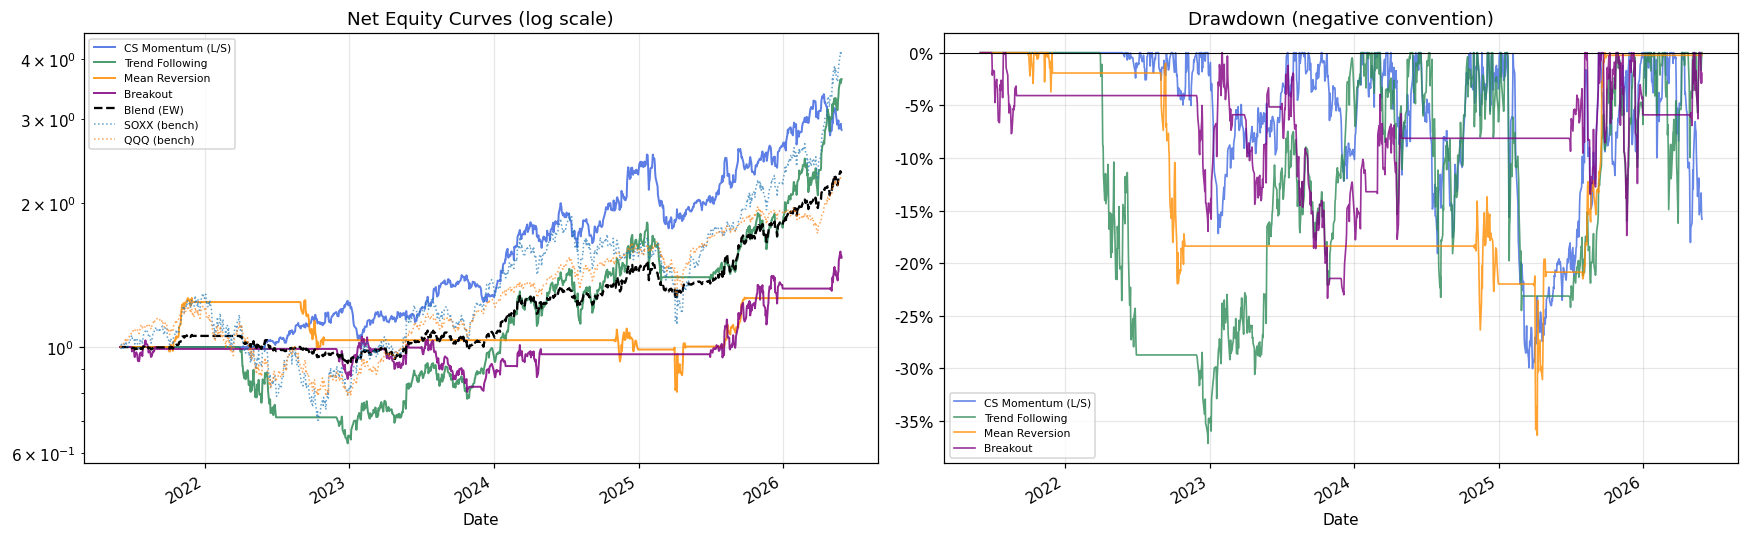

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

COLOURS = {'CS Momentum (L/S)': 'royalblue', 'Trend Following': 'seagreen',
           'Mean Reversion': 'darkorange', 'Breakout': 'purple', 'Blend': 'black'}

# Equity curves
ax = axes[0]
for name, bt in [('CS Momentum (L/S)', bt_cs), ('Trend Following', bt_tf),
                  ('Mean Reversion', bt_mr), ('Breakout', bt_bo)]:
    bt['equity_net'].plot(ax=ax, label=name, color=COLOURS.get(name), linewidth=1.3, alpha=0.85)
(1 + blend_net).cumprod().plot(ax=ax, label='Blend (EW)', color='black', linewidth=1.5, linestyle='--')

for bname in [PRIMARY_BENCH, 'QQQ']:
    if bname in bench_rets:
        (1 + bench_rets[bname]).cumprod().plot(ax=ax, label=f'{bname} (bench)',
                                                linewidth=1, linestyle=':',  alpha=0.7)
ax.set_title('Net Equity Curves (log scale)')
ax.set_yscale('log')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Drawdown curves
ax = axes[1]
for name, bt in [('CS Momentum (L/S)', bt_cs), ('Trend Following', bt_tf),
                  ('Mean Reversion', bt_mr), ('Breakout', bt_bo)]:
    eq = bt['equity_net']
    dd = (eq - eq.cummax()) / eq.cummax()
    dd.plot(ax=ax, label=name, color=COLOURS.get(name), linewidth=1.1, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Drawdown (negative convention)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Plot Rolling Sharpe Ratio & Cost Impact


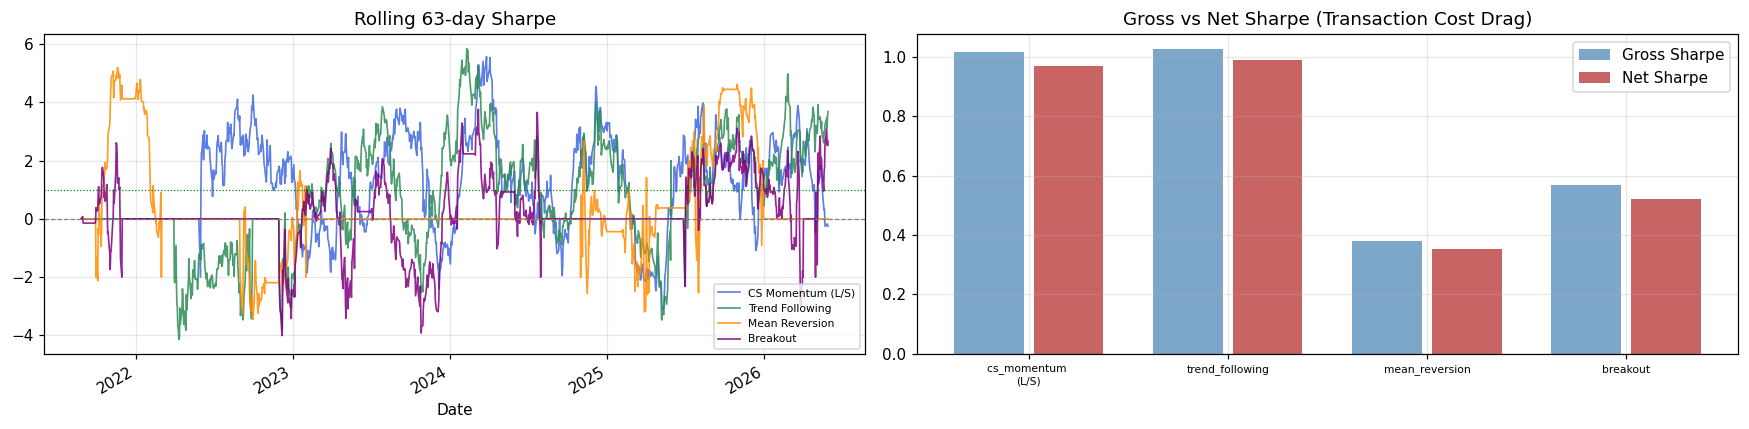

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Rolling 63-day Sharpe
ax = axes[0]
for name, bt in [('CS Momentum (L/S)', bt_cs), ('Trend Following', bt_tf),
                  ('Mean Reversion', bt_mr), ('Breakout', bt_bo)]:
    r = bt['net']
    rs = r.rolling(63).mean() / (r.rolling(63).std() + 1e-9) * np.sqrt(252)
    rs.plot(ax=ax, label=name, color=COLOURS.get(name), linewidth=1.1, alpha=0.85)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axhline(1, color='green', linewidth=0.8, linestyle=':')
ax.set_title('Rolling 63-day Sharpe')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Strategy comparison (gross vs net Sharpe)
ax = axes[1]
strats_plot = ['cs_momentum (L/S)', 'trend_following', 'mean_reversion', 'breakout']
xs = np.arange(len(strats_plot))
gross_s = [strategy_metrics[s].get('gross_sharpe', 0) for s in strats_plot]
net_s   = [strategy_metrics[s].get('sharpe_ratio', 0) for s in strats_plot]
ax.bar(xs - 0.2, gross_s, 0.35, label='Gross Sharpe', color='steelblue', alpha=0.7)
ax.bar(xs + 0.2, net_s,   0.35, label='Net Sharpe',   color='firebrick', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(xs)
ax.set_xticklabels([s.replace('(', '\n(') for s in strats_plot], fontsize=7)
ax.set_title('Gross vs Net Sharpe (Transaction Cost Drag)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Export Results to Local Outputs


In [13]:
import os
from datetime import datetime, timezone

ts = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
run_dir = os.path.join(OUTPUT_DIR, ts)
os.makedirs(run_dir, exist_ok=True)

# 1. Strategy returns time-series
returns_df = pd.DataFrame({
    'cs_momentum_net': bt_cs['net'],
    'trend_following_net': bt_tf['net'],
    'mean_reversion_net': bt_mr['net'],
    'breakout_net': bt_bo['net'],
    'blend_net': blend_net,
    **{f'bench_{k}': v for k, v in bench_rets.items()},
})
returns_df.to_csv(os.path.join(run_dir, 'strategy_returns.csv'))

# 2. Metrics summary
metrics_df.to_csv(os.path.join(run_dir, 'strategy_results_summary.csv'))

# 3. List of symbols in traded universe
pd.DataFrame({'symbol': list(valid_close.columns)}).to_csv(
    os.path.join(run_dir, 'universe_used.csv'), index=False
)

if skipped:
    pd.DataFrame({'symbol': skipped}).to_csv(
        os.path.join(run_dir, 'skipped_symbols.csv'), index=False
    )

print(f'CSVs successfully written to: {run_dir}')


CSVs successfully written to: outputs/research_runs/ai_infrastructure/20260530_062228


## 14. Compile and Save Markdown Report


In [14]:
results_for_report = {
    'universe_used': list(valid_close.columns),
    'symbols_skipped': skipped,
    'validation_report': val_report,
    'period': PERIOD,
    'interval': INTERVAL,
    'cost_bps': TOTAL_COST_BPS,
    'long_only': LONG_ONLY,
    'rf_annual': 0.0,
    'primary_benchmark': PRIMARY_BENCH,
    'run_timestamp': datetime.now(timezone.utc).isoformat(),
    'duration_seconds': 0,
    'disclaimer': 'RESEARCH / EDUCATIONAL PURPOSES ONLY. NOT INVESTMENT ADVICE.',
    'agent_review': agent_review_text,
    'strategies': {
        'cross_sectional_momentum': {
            'verdict': 'marginal_positive' if strategy_metrics.get('cs_momentum (L/S)', {}).get('sharpe_ratio', 0) > 0.5 else 'unprofitable',
            'metrics_net': strategy_metrics.get('cs_momentum (L/S)', {}),
            'metrics_gross': {'sharpe_ratio': strategy_metrics.get('cs_momentum (L/S)', {}).get('gross_sharpe')},
            'alpha_beta': {k.replace('alpha_', ''): v for k, v in strategy_metrics.get('cs_momentum (L/S)', {}).items() if k.startswith('alpha_')},
            'is_metrics': {}, 'oos_metrics': {},
            'hypothesis': 'Cross-sectional 12-1 momentum, monthly rebalance, L/S dollar-neutral.',
            'is_primary': True,
            'backtest': {'net': bt_cs['net'], 'gross': bt_cs['gross'], 'equity_net': bt_cs['equity_net'],
                         'equity_gross': bt_cs['equity_gross'], 'turnover_per_rebal': bt_cs['turnover_per_rebal'],
                         'cost_drag': bt_cs['cost_drag'], 'n_rebal': bt_cs['n_rebal']},
        },
    },
    'bench_summary': {bname: calculate_strategy_metrics(bret) for bname, bret in bench_rets.items()},
}

report_path = os.path.join(run_dir, 'report.md')
generate_ai_infra_report(results_for_report, report_path)
print(f'Report written to: {report_path}\n')

with open(report_path) as f:
    print(f.read())


Report written to: outputs/research_runs/ai_infrastructure/20260530_062228/report.md

# AI Infrastructure & Semiconductor — Alpha Research Report

**Generated:** 2026-05-30T06:22:28.107062+00:00
**Universe:** 32 symbols (5y | 1d)
**Cost:** 20 bps round-trip
**rf = 0.0%** (no FRED — overstates long-only Sharpe in high-rate environments)

> **DISCLAIMER:** RESEARCH / EDUCATIONAL PURPOSES ONLY. NOT INVESTMENT ADVICE.

---

## Strategy Results (net of costs)

| Strategy | Verdict | Net Sharpe | Ann. Return | Max DD | Alpha vs Bench | t(α) | Turnover/rebal |
|---|---|---|---|---|---|---|---|
| Cross Sectional Momentum | marginal_positive | 0.969 | 23.37% | -30.03% | 20.86% | 1.88 | 0.680 |

## Cross-Sectional Momentum — IS/OOS Stability
(Split at temporal midpoint — not chosen to flatter results.)

- In-sample Sharpe : **nan**
- Out-of-sample Sharpe : **nan**

## Benchmark Comparison

| Benchmark | Sharpe | Ann. Return | Max DD |
|---|---|---|---|
| SOXX | 0.969 | 32.91% | -45.75% |
| SMH |

## 15. Honest Research Conclusions


In [15]:
print('=' * 65)
print('  HONEST RESEARCH CONCLUSION')
print('=' * 65)
print(f'  Universe: {len(valid_close.columns)} symbols | Period: {PERIOD}')
print()

_VERDICT_MAP = {
    'promising':        'Sharpe > 1.0 and alpha t-stat > 2 — worth further stress-testing',
    'marginal_positive':'0.5 < Sharpe ≤ 1.0 — positive edge, cost-sensitive',
    'marginal':         '0 < Sharpe ≤ 0.5 — weak positive edge',
    'unprofitable':     'Sharpe ≤ 0 — strategy lost money after costs',
    'no_results':       'No trades generated',
}

for name, bt in [('CS Momentum (L/S)', bt_cs), ('Trend Following', bt_tf),
                  ('Mean Reversion', bt_mr), ('Breakout', bt_bo)]:
    m = calculate_strategy_metrics(bt['net'])
    sr = m.get('sharpe_ratio', float('nan'))
    ab = calculate_alpha_beta_vs_benchmark(bt['net'], primary_bench_ret)
    ta = ab.get('t_alpha', float('nan'))
    if np.isnan(sr):           verdict = 'no_results'
    elif sr > 1.0 and abs(ta) >= 2.0: verdict = 'promising'
    elif sr > 0.5:             verdict = 'marginal_positive'
    elif sr > 0.0:             verdict = 'marginal'
    else:                      verdict = 'unprofitable'
    desc = _VERDICT_MAP[verdict]
    print(f'  {name:22s}  Sharpe={sr:6.3f}  t(α)={ta:5.2f}  → {verdict}')
    print(f'    {desc}\n')

print('  Suggested next steps:')
print('  1. Walk-forward validation (rolling IS/OOS windows).')
print('  2. Regime filter (VIX > 30 = reduce exposure).')
print('  3. Parameter sensitivity: vary lookback ±50 days.')
print('  4. Survivorship-bias correction (add delisted names).')
print('  5. Liquidity-weighted position sizing.')
print('=' * 65)


  HONEST RESEARCH CONCLUSION
  Universe: 32 symbols | Period: 5y

  CS Momentum (L/S)       Sharpe= 0.969  t(α)= 1.88  → marginal_positive
    0.5 < Sharpe ≤ 1.0 — positive edge, cost-sensitive

  Trend Following         Sharpe= 0.990  t(α)= 0.93  → marginal_positive
    0.5 < Sharpe ≤ 1.0 — positive edge, cost-sensitive

  Mean Reversion          Sharpe= 0.354  t(α)=-0.10  → marginal
    0 < Sharpe ≤ 0.5 — weak positive edge

  Breakout                Sharpe= 0.521  t(α)= 0.27  → marginal_positive
    0.5 < Sharpe ≤ 1.0 — positive edge, cost-sensitive

  Suggested next steps:
  1. Walk-forward validation (rolling IS/OOS windows).
  2. Regime filter (VIX > 30 = reduce exposure).
  3. Parameter sensitivity: vary lookback ±50 days.
  4. Survivorship-bias correction (add delisted names).
  5. Liquidity-weighted position sizing.
